# Notebook 6 — BNE Growth Rate and Saturation

## What we do here

In Notebook 4 we computed BNE for a single LAE size ($n = 30$). Here we load the
pre-computed BNE values for $n = 1, 2, \ldots, 80$ (computed by `5_BNE_workflow.py`)
and analyse how BNE grows with $n$.

**Reference:** K. Iwanowski, G. Csányi, and M. Simoncelli,
*Phys. Rev. X* **15**, 041041 (2025)

---

## Theory: growth rate and saturation

As we increase the LAE size $n$:
- At **small $n$**: most atoms see identical tiny environments → BNE is small.
- At **intermediate $n$**: the number of distinct ring environments grows roughly exponentially, BNE grows linearly.
  The **slope** BNE$(n)/n$ in this regime is the material fingerprint.
- At **large $n$**: the environment is so big that local environments become unique, so BNE saturates.

The theoretical **maximum** is $S_{\max} = \ln(N)$, reached if every atom had a completely
unique barcode. For $N = 5184$ atoms: $\ln(5184) \approx 8.55$ nats.

The function `normalised_BNE` estimates the growth rate by averaging BNE$(n)/n$ over a
range $[n_{\rm start}, n_{\rm stop}]$ that sits in the linear regime (avoiding the early
transient at small $n$ and the saturation effects at large $n$).

In [1]:
import os, sys

import numpy as np
import pandas as pd
import scipy
from scipy.constants import physical_constants

import ase
from ase.io import read, write

matplotlib_style = 'fivethirtyeight'
import matplotlib.pyplot as plt
plt.style.use(matplotlib_style)
import seaborn as sns
sns.set_context('notebook')

class _Colors(object):
    """Helper class with different colors for plotting"""
    red = '#F15854'
    blue = '#5DA5DA'
    orange = '#FAA43A'
    green = '#60BD68'
    pink = '#F17CB0'
    brown = '#B2912F'
    purple = '#B276B2'
    yellow = '#DECF3F'
    gray = '#4D4D4D'
    cyan = '#00FFFF'
    rebecca_purple = '#663399'
    chartreuse = '#7FFF00'
    dark_red = '#8B0000'

    def __getitem__(self, i):
        color_list = [
            self.red,
            self.orange,
            self.green,
            self.blue,
            self.pink,
            self.brown,
            self.purple,
            self.yellow,
            self.gray,
            self.cyan,
            self.rebecca_purple,
            self.chartreuse,
            self.dark_red
        ]
        return color_list[i % len(color_list)]


Colors = _Colors()

from typing import Tuple, List
from tqdm import tqdm


In [2]:
import h5py

In [3]:
BNE_data_directory = "./data/bond_network_entropy"

BNE_data = {}

structure_idx = 0

temp_BNE = []
temp_nat = []
for LE_nat in range(1, 81):
    with h5py.File(f"{BNE_data_directory}/structure_{structure_idx}/entropy_number_{LE_nat}.hdf5", "r") as f:
        temp_BNE.append(np.asarray(f['entropy'])[0])
        temp_nat.append(np.asarray(f['number_of_atoms'])[0])

temp_BNE, temp_nat = np.array(temp_BNE), np.array(temp_nat)

BNE_data[f"{structure_idx}_BNE"] = temp_BNE
BNE_data[f"{structure_idx}_nat"] = temp_nat

n_start, n_stop = 10, 40

def normalised_BNE(n_atoms, entropy, n_start=n_start, n_stop=n_stop):
    """
    Estimate the BNE growth rate by averaging BNE(n)/n over [n_start, n_stop].

    n_start=10 avoids the early transient (small environments
    look identical); n_stop=40 avoids the saturation regime (large environments
    start to become unique, bending the curve).

    Returns
    -------
    BNE_mean : float
        Mean BNE(n)/n in nats per atom — the growth rate estimate.
    BNE_std : float
        Standard deviation of BNE(n)/n over the window.
    """
    idx_start = np.arange(0, len(n_atoms), 1)[n_atoms == n_start][-1]
    idx_stop  = np.arange(0, len(n_atoms), 1)[n_atoms == n_stop][0]

    local_n_atoms  = n_atoms[idx_start:idx_stop+1]
    local_quotient = entropy[idx_start:idx_stop+1] / local_n_atoms

    BNE_mean = np.mean(local_quotient)
    BNE_std  = np.std(local_quotient, ddof=1)

    return BNE_mean, BNE_std

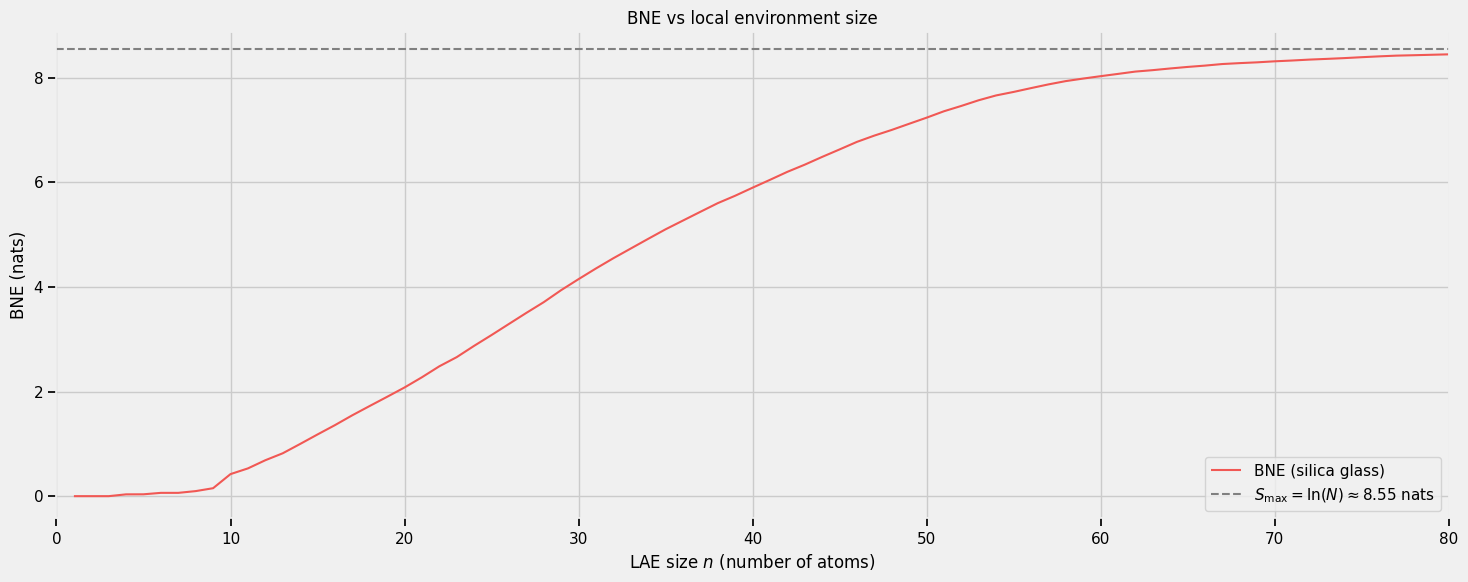

Growth rate (BNE/n averaged over n=10–40): 0.1139 ± 0.0327 nats/atom


In [4]:
n_atoms_silica = 5184
S_max = np.log(n_atoms_silica)  # theoretical maximum BNE

structure_idx = 0
nat  = BNE_data[f"{structure_idx}_nat"]
bne  = BNE_data[f"{structure_idx}_BNE"]

plt.figure(figsize=(16, 6))
plt.plot(nat, bne, color=Colors[0], label="BNE (silica glass)")
plt.axhline(S_max, color='gray', linestyle='--', label=rf"$S_{{\max}} = \ln(N) \approx {S_max:.2f}$ nats")
plt.ylabel("BNE (nats)")
plt.xlabel("LAE size $n$ (number of atoms)")
plt.xlim([0, 80])
plt.legend()
plt.title("BNE vs local environment size")
plt.show()

bne_mean, bne_std = normalised_BNE(nat, bne)
print(f"Growth rate (BNE/n averaged over n={n_start}–{n_stop}): {bne_mean:.4f} ± {bne_std:.4f} nats/atom")

## Where does BNE saturate?

From the plot above, BNE grows roughly linearly up to $n \approx 50$, after which the
curve clearly bends over and approaches $S_{\max}$. By $n = 80$, BNE $\approx 8.45$ nats,
within $\sim 0.1$ nats of the ceiling $S_{\max} = \ln(N) \approx 8.55$ nats — saturation
is essentially complete.

By linearly extrapolating the growth rate (estimated in the $n = 10$–$40$ linear regime)
to the saturation ceiling, we can estimate the LAE size $n^*$ at which saturation occurs:

$$n^* \approx \frac{S_{\max}}{\text{growth rate}} = \frac{\ln(N)}{\text{BNE}(n)/n}$$

For silica, this predicts $n^* \approx 75$ atoms, consistent with what we see in the data:
the curve has nearly reached $S_{\max}$ by $n = 75$–$80$.

In [5]:
n_star = S_max / bne_mean
print(f"Estimated saturation LAE size: n* ≈ {n_star:.0f} atoms")
print(f"(where the linear extrapolation reaches S_max = ln({n_atoms_silica}) = {S_max:.2f} nats)")

Estimated saturation LAE size: n* ≈ 75 atoms
(where the linear extrapolation reaches S_max = ln(5184) = 8.55 nats)
